In [1]:
import io 
import os 
import sys
import h5py
from matplotlib.lines import lineStyles 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import matplotlib.cbook as cbook
import seaborn as sns
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

down_file = 'hydro_ds_2018_4-1_10-31-MZT.txt'
up_file = 'hydro_us_2018_4-1_10-31-MZT.txt'
down_bc = pd.read_csv(down_file,sep='\t', header=2, index_col= False)
up_bc_w_dam = pd.read_csv(up_file,sep='\t', header=2, index_col=False)
gdrive = '/Users/christiandewey/Library/CloudStorage/GoogleDrive-christian.w.dewey@gmail.com/My Drive/manuscripts/2023_Dewey-Fendorf-etal_meanders/plots/'

0       1.4631
1       1.4631
2       1.4724
3       1.4868
4       1.4980
         ...  
5127    1.4251
5128    1.4357
5129    1.4439
5130    1.4451
5131    1.4468
Name: z, Length: 5132, dtype: float64


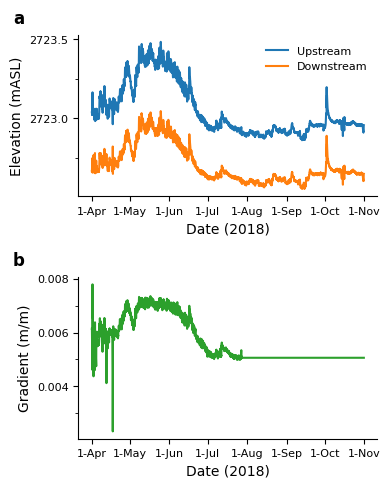

In [3]:
mc_len = 61 # m
base_elev = 2721.2 # mASL 
up_elev = []

startdate = np.datetime64('2018-04-01')
switch_date = np.datetime64('2018-07-28')


tdiff_h = 118 * 24
for z_up, z_down, h in zip(up_bc_w_dam['z'], down_bc['z'], down_bc['!h']):
    
    if h == tdiff_h:
        delta_z = z_up - z_down

    if h <= tdiff_h:
        up_elev.append(z_up)
    else:
        up_elev.append(z_down + delta_z)



xpltl = -0.2
ypltl = 1.1 


upstream_bc = {'!h': down_bc['!h'], 'x': down_bc['x'], 'y': down_bc['y'], 'z': up_elev}
df = pd.DataFrame.from_dict(upstream_bc)


bc_list = []
for i in range(len(df)):
    row_i = df.iloc[i,:]
    bc_list.append(f"{row_i['!h']:.3E}\t{row_i['x']:.3E}\t{row_i['y']:.3E}\t{row_i['z']:.3E}\n" )

if os.path.exists('mzt-NODAM_up_2018_4-1_10-31-MZT.txt'):
        os.remove('mzt-NODAM_up_2018_4-1_10-31-MZT.txt')

header_lines = ["TIME_UNITS h\n","DATA_UNITS m\n","!h	x	y	z\n"]
with open('mzt-NODAM_up_2018_4-1_10-31-MZT.txt','a') as file:
     file.writelines(header_lines)
     file.writelines(bc_list)



mpl.rcParams['mathtext.default'] = 'rm'
mpl.rcParams['legend.fontsize'] = 8
mpl.rcParams['axes.labelsize'] = 10
mpl.rcParams['xtick.labelsize'] = 8
mpl.rcParams['ytick.labelsize'] = 8

times = [np.timedelta64(int(t),'h') for t in upstream_bc['!h']]
datex = [(startdate + dt) for dt in times]
timesx = datex 

fig, (ax, ax1) = plt.subplots(2, 1, figsize=(4,5))
print(down_bc['z'])
ax.plot(timesx, np.array(up_elev)+base_elev, label = 'Upstream')
ax.plot(timesx, np.array(down_bc['z'])+base_elev, label = 'Downstream')
ax.set_ylabel('Elevation (mASL)')
ax.set_xlabel('Date (2018)')

ax.legend(frameon = False, bbox_to_anchor=(1.0,0.85),loc='center right')

ax1.plot(timesx, (np.array(up_elev)-np.array(down_bc['z']))/mc_len, color = 'C2')
ax1.set_ylabel('Gradient (m/m)')
ax1.set_xlabel('Date (2018)')

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%-d-%b"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%-d-%b"))
import matplotlib.ticker as tick
ax.yaxis.set_major_formatter(tick.FormatStrFormatter('%.1f'))

minor_locator = AutoMinorLocator(2)
ax.yaxis.set_minor_locator(minor_locator)
major_locator = MultipleLocator(0.5)
ax.yaxis.set_major_locator(major_locator)

minor_locator = AutoMinorLocator(2)
ax1.yaxis.set_minor_locator(minor_locator)
major_locator = MultipleLocator(0.002)
ax1.yaxis.set_major_locator(major_locator)

ax = ax 
ax.text(xpltl, ypltl,'a',
        horizontalalignment='center',
        verticalalignment='center',
        transform = ax.transAxes, fontweight='bold', fontsize = 12)


ax = ax1
ax.text(xpltl, ypltl,'b',
        horizontalalignment='center',
        verticalalignment='center',
        transform = ax.transAxes, fontweight='bold', fontsize = 12)


sns.despine()
fig.tight_layout()

plt.savefig(gdrive + 'MZ-noDam_2018_bcs+gradient_240102.pdf', bbox_inches = 'tight')